In [1]:
import numpy as np
from sklearn.metrics import mean_squared_error
from scipy.integrate import odeint
from scipy.optimize import minimize
import matplotlib.pylab as plt
from matplotlib.pylab import rcParams
import optuna
plt.style.use('seaborn-colorblind')
%matplotlib inline
%load_ext autotime

N = 3711          # community size
t_max = 12
tspan = np.linspace(0.0, t_max, t_max + 1)

# parameters to fit
alpha = 0.0       # 感染者の発症率 
I0 = 0            # Init Infected patients
beta = 0.0        # infection force
gamma = 0.0       # 14日で感染力がなくなる

# Data to be fitted
dI_observed = [16,31,18,24,10,18,12,16,5,1,0,0]

def sir(v,t):
    global alpha, beta, gamma
    # v = [S, I, R]
    x = beta*v[0]*v[2]   # その日の新たな感染者数
    dS = -x              # 感受性宿主の差分
    dR = gamma * v[1]    # 感染者の中でその日に回復する数（回復者数の差分）
    dI = x - dR          # 感染者数の増減
    return np.array([dS, dI, dR])

def objective(trial):
    global beta,gamma,alpha,I0
    # パラメタ空間の定義
    alpha = trial.suggest_uniform('alpha', 0.001, 0.1)  # 1日あたり発症率 0.1% - 10%
    beta = trial.suggest_loguniform('beta', 1e-5, 1e-1) # 感染率 0.001% - 10%
    gamma = trial.suggest_uniform('gamma', 0.05, 0.5)   # 感染期間 2日 - 20日
    I0 = trial.suggest_uniform('I0', 0, 1000 )          # 2/5時の感染者 0 - 1,000人
    ini_state = [N-I0, I0, 0]   # 初期状態の感受性宿主数、感染者数、回復者数
    ode_int = odeint(sir, ini_state, tspan)  # 0日後 - 12日後のS, I, Rを計算
    x = (alpha * ode_int[:,1])[1:]           # 1日後 - 12日後の発症者数
    return mean_squared_error(x, dI_observed)  # 観測データとの2乗誤差

optuna.logging.disable_default_handler()
study = optuna.create_study()
study.optimize(objective, n_trials=100)
print("best_value = ", study.best_value)
print("best_params = ", study.best_params)

best_value =  43.85197947106382
best_params =  {'alpha': 0.03481881092569136, 'beta': 1.2197770580106738e-05, 'gamma': 0.1671424100025477, 'I0': 865.3999864236297}


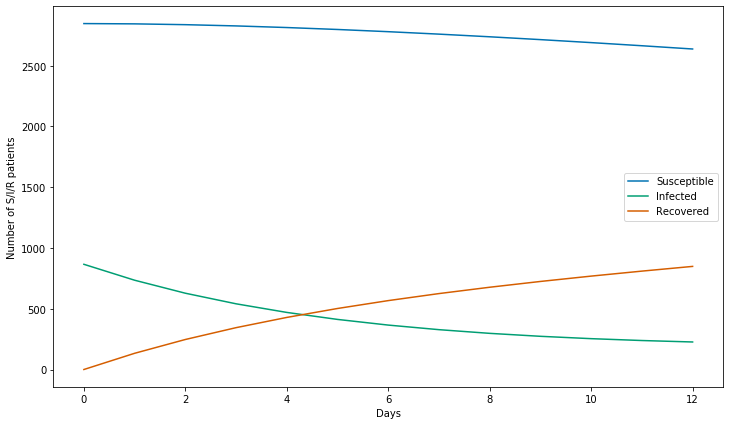

time: 171 ms


In [2]:
I0 = study.best_params['I0']
alpha = study.best_params['alpha']
beta = study.best_params['beta']
gamma = study.best_params['gamma']

ini_state = [N-I0, I0, 0]

rcParams['figure.figsize'] = 12, 7
ode_int = odeint(sir, ini_state, tspan)
plt.plot(ode_int)
plt.legend(['Susceptible', 'Infected', 'Recovered'])
plt.xlabel('Days')
plt.ylabel('Number of S/I/R patients')
plt.show()